In [1]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_as_a_percentage_of_registered_voters,absentee_as_percentage_of_total_ballots,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
0,BALDWIN,207643,122542,59.02,6.34,0.5902,0.0634,253507.0,10.0,8.268600,32.797637,0.096326
1,BARBOUR,17666,9919,56.15,5.98,0.5615,0.0598,24585.0,25.5,22.186295,11.464715,0.096326
2,BULLOCK,7181,4144,57.71,9.80,0.5771,0.0980,9897.0,33.6,25.955544,8.999729,0.106456
3,BUTLER,14530,8530,58.71,5.44,0.5871,0.0544,18382.0,23.6,12.405044,13.764813,0.098743
4,CHOCTAW,10767,6692,62.15,6.75,0.6215,0.0675,12252.0,24.8,15.781285,13.914203,0.113017


In [3]:
candidate_features = [
    "turnout_rate",
    "poverty_rate",
    "pct_less_hs",
    "pct_bachelors",
    "age_18_29_share"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
0,0.5902,10.0,8.268600,32.797637,0.096326
1,0.5615,25.5,22.186295,11.464715,0.096326
2,0.5771,33.6,25.955544,8.999729,0.106456
3,0.5871,23.6,12.405044,13.764813,0.098743
4,0.6215,24.8,15.781285,13.914203,0.113017


In [4]:
pca_df.describe()

,turnout_rate,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
count,25.000000,24.000000,24.000000,24.000000,25.000000
mean,0.575536,24.416667,15.467159,17.476680,0.109385
std,0.047023,6.375747,4.094101,6.534449,0.013617
min,0.446800,10.000000,8.268600,8.999729,0.085848
25%,0.551600,19.075000,12.414252,12.969478,0.098743
50%,0.588500,23.700000,15.256294,16.488905,0.107438
75%,0.615700,29.800000,17.557432,19.374789,0.115842
max,0.626500,33.800000,25.955544,34.274028,0.150505


In [ ]:
# Lower turnout = higher risk
pca_df["turnout_rate"] = 1 - pca_df["turnout_rate"]

# Higher bachelor's attainment = lower risk
if pca_df["pct_bachelors"].max() > 1:
    pca_df["pct_bachelors"] = pca_df["pct_bachelors"] / 100
pca_df["pct_bachelors"] = 1 - pca_df["pct_bachelors"]

# Less than high school should point toward higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
0,0.4098,10.0,0.082686,0.672024,0.096326
1,0.4385,25.5,0.221863,0.885353,0.096326
2,0.4229,33.6,0.259555,0.910003,0.106456
3,0.4129,23.6,0.124050,0.862352,0.098743
4,0.3785,24.8,0.157813,0.860858,0.113017


In [6]:
pca_df.isna().sum()

turnout_rate       0
poverty_rate       1
pct_less_hs        1
pct_bachelors      1
age_18_29_share    0
dtype: int64

In [7]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,turnout_rate,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
0,0.4098,10.0,0.082686,0.672024,0.096326
1,0.4385,25.5,0.221863,0.885353,0.096326
2,0.4229,33.6,0.259555,0.910003,0.106456
3,0.4129,23.6,0.124050,0.862352,0.098743
4,0.3785,24.8,0.157813,0.860858,0.113017


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [10]:
corr = X_imputed.corr()
corr

,turnout_rate,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share
turnout_rate,1.000000,-0.011891,-0.120380,-0.259497,0.134262
poverty_rate,-0.011891,1.000000,0.554505,0.506597,-0.319343
pct_less_hs,-0.120380,0.554505,1.000000,0.688014,-0.132724
pct_bachelors,-0.259497,0.506597,0.688014,1.000000,-0.325243
age_18_29_share,0.134262,-0.319343,-0.132724,-0.325243,1.000000


In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [12]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.474228,0.474228
1,PC2,0.203592,0.677820
2,PC3,0.177369,0.855189
3,PC4,0.091658,0.946847
4,PC5,0.053153,1.000000


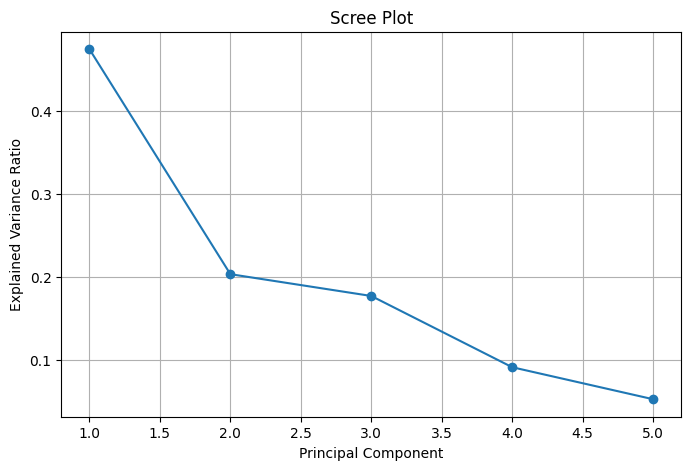

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5
turnout_rate,-0.190124,0.887858,-0.276250,-0.303951,-0.082826
poverty_rate,0.502497,0.318746,-0.127229,0.776705,-0.162606
pct_less_hs,0.535398,0.215855,0.371080,-0.229696,0.690142
pct_bachelors,0.566646,-0.048194,0.159607,-0.459535,-0.663282
age_18_29_share,-0.321887,0.247371,0.862742,0.201025,-0.224636


In [16]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-3.174659
1,BARBOUR,1.805387
2,BULLOCK,3.027384
3,BUTLER,0.155285
4,CHOCTAW,0.498214


In [17]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,BARBOUR,80.296867
2,BULLOCK,100.000000
3,BUTLER,53.691077
4,CHOCTAW,59.220380


In [18]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
2,BULLOCK,100.000000
23,WILCOX,85.585315
10,GREENE,81.717471
1,BARBOUR,80.296867
12,LOWNDES,72.969549
18,PERRY,71.481445
6,CONECUH,61.295391
21,SUMTER,61.125700
4,CHOCTAW,59.220380
11,HALE,58.609704


In [19]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)